In [1]:
# When you create a new instance of EnvironmentData and there is no database, it'll pull historical data and initialize the database. 
from EnvironmentData import EnvironmentData 
#envdt = EnvironmentData(CatsUserID = 2496, out_of_scope = ['-80', 'Cryo tank', 'Water'], testing = True)
envdt = EnvironmentData(CatsUserID = 2496, out_of_scope = ['-80', 'Cryo tank', 'Water'])

Gather readings: SensorReadingRh: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 65/65 [01:13<00:00,  1.14s/it]


In [2]:
# Detailed info is saved in the log.
with open('data/EnvironmentData.log', 'r') as file:
    print(file.read())

2024-10-10 17:32:24,759 - EnvironmentData - INFO - initialize_database
2024-10-10 17:32:24,759 - EnvironmentData - INFO - get_sensors
2024-10-10 17:32:24,759 - EnvironmentData - INFO - API call: https://cats.corismonitoring.com/api/cats/user/?ApiKey=XXXX&CatsUserID=XXXX
2024-10-10 17:32:25,768 - EnvironmentData - INFO - API call: https://cats.corismonitoring.com/api/sensor/historical/?ApiKey=XXXX&SensorID=21373&ReadingType=SensorReadingF&StartUTC=1720827144&EndUTC=1728603144&MinReadingSpacing=600&RequestedOutputFormat=raw
2024-10-10 17:32:27,412 - EnvironmentData - INFO - API call: https://cats.corismonitoring.com/api/sensor/historical/?ApiKey=XXXX&SensorID=21375&ReadingType=SensorReadingF&StartUTC=1720827144&EndUTC=1728603144&MinReadingSpacing=600&RequestedOutputFormat=raw
2024-10-10 17:32:28,595 - EnvironmentData - INFO - API call: https://cats.corismonitoring.com/api/sensor/historical/?ApiKey=XXXX&SensorID=21377&ReadingType=SensorReadingF&StartUTC=1720827144&EndUTC=1728603144&MinRea

In [3]:
# Data is now in the database.
# Columns are limited because it is historcal data. We'll expand the data once we are pulling full data. 
import polars
polars.read_parquet('data/sensors.parquet')

DeviceDevID,DeviceName,SensorID,SensorReadingUTC,SensorReadingF,SensorReadingRh,SensorName,SensorType
i32,str,i32,i64,f32,f32,str,str
12162,"""Peabody TH-L Mammal Hall D444""",21373,1720827144,69.730003,null,"""Temp YPM 104_D444""","""Temperature"""
12162,"""Peabody TH-L Mammal Hall D444""",21373,1720827744,69.660004,null,"""Temp YPM 104_D444""","""Temperature"""
12162,"""Peabody TH-L Mammal Hall D444""",21373,1720828344,69.669998,null,"""Temp YPM 104_D444""","""Temperature"""
12162,"""Peabody TH-L Mammal Hall D444""",21373,1720828944,69.730003,null,"""Temp YPM 104_D444""","""Temperature"""
12162,"""Peabody TH-L Mammal Hall D444""",21373,1720829544,69.690002,null,"""Temp YPM 104_D444""","""Temperature"""
…,…,…,…,…,…,…,…
15179,"""C352 Yale Peabody 6.19.24""",30138,1728600144,null,42.700001,"""RH ESC 385_C352""","""Humidity"""
15179,"""C352 Yale Peabody 6.19.24""",30138,1728600744,null,43.700001,"""RH ESC 385_C352""","""Humidity"""
15179,"""C352 Yale Peabody 6.19.24""",30138,1728601344,null,42.700001,"""RH ESC 385_C352""","""Humidity"""


In [4]:
# Get current readings. 
envdt.get_current_readings()

# Data is read into new-readings folder for consolidation at the end of the day.
import os
polars.read_parquet('data/new-readings/' + os.listdir('data/new-readings')[0]).sample(5)

SensorName,SensorID,SensorPort,ServerUTC,HexGatewayMac,LoraHexGatewayMac,LoraGatewayLastHeardUTC,SensorUnplugged,LinkQualityText,HexMac,SensorDeleted,SensorDeactivated,SensorReading,SensorReadingUTC,DeviceName,DevTypeInt,DeviceDevID,SensorTempPref,DeviceTempPref,UserTempPref,SensorTimeZone,SensorZipcode,SensorType,SensorState0String,SensorState1String,LN2LevelADCThresh,LN2LevelADCThreshCatsUserID,LN2LevelADCThreshModifiedUTC,DiscreteLightSensorADCThresh,DiscreteLightSensorADCThreshCatsUserID,DiscreteLightSensorADCThreshModifiedUTC,DiscreteLightSensorOnOffLuxThreshold,DiscreteLightSensorOnOffLuxThresholdCatsUserID,DiscreteLightSensorOnOffLuxThresholdModifiedUTC,ExpectedSensorReadingIntervalSeconds,SensorReadingC,SensorCalibrationOffsetC,SensorReadingF,SensorCalibrationOffsetF,SensorCalibrationOffsetExplanationText,SensorCalibrationOffsetExplanationFirstName,SensorCalibrationOffsetExplanationLastName,SensorCalibrationOffsetUTC,LoraBatteryPresent,LoraBattery_mV,LoraBatteryPercentage,LoraBatteryUTC,LoraBatteryIsCharging,LastSensorErrorValue,LastSensorErrorUTC,UnivID,SensorSerialNumber,HeatIndexRh,ConjoinedRhSensorSensorReadingRh,ConjoinedRhSensorSensorID,ConjoinedRhSensorSensorReadingUTC,SensorReadingHeatIndexF,SensorReadingHeatIndexC,HeatIndexWarningTier,LoraExternalPowerPresent,SensorReadingRh,SensorCalibrationOffsetRh,SensorEventCount,SensorState
str,i64,i64,i64,str,str,i64,bool,str,str,bool,bool,f64,i64,str,i64,i64,str,null,str,str,null,str,str,str,null,null,null,null,null,null,null,null,null,i64,f64,f64,f64,f64,str,str,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,null,f64,f64,i64,i64,f64,f64,i64,i64,f64,i64,i64,str
"""RH ESC 285_86a624""",28878,0,1728603294,"""000000000000""","""0080000000019E54""",1728603290,null,"""Good""","""A84041D8C186A624""",false,false,48.9,1728603145,"""YalePeabody 8.23.23 A624""",112,14490,null,null,"""F""","""America/New_York""",null,"""Humidity""",null,null,null,null,null,null,null,null,null,null,null,300,null,null,null,null,null,null,null,null,1,null,85,1728603126,0,null,null,43327,null,null,null,null,null,null,null,null,0,48.9,0,null,null
"""Temp YPM 104_D444""",21373,0,1728603294,"""000000000000""","""00800000000207AF""",1728603287,false,"""Excellent""","""0025CA0A0000D444""",false,false,20.52,1728603222,"""Peabody TH-L Mammal Hall D444""",96,12162,null,null,"""F""","""America/New_York""",null,"""Temperature""",null,null,null,null,null,null,null,null,null,null,null,null,20.5,0.0,68.9,0.0,null,null,null,null,1,0,55,1728602020,0,null,null,33501,null,55.0,55.0,21374,1728603222,68.9,20.5,0,0,null,null,null,null
"""Temp KGL 105_8404fd""",25966,0,1728603294,"""000000000000""","""0080000000019E44""",1728603276,false,"""Good""","""A8404159618404FD""",false,false,20.38,1728603183,"""Yale Peabody 8404fd""",112,12922,null,null,"""F""","""America/New_York""",null,"""Temperature""",null,null,null,null,null,null,null,null,null,null,null,300,20.4,0.0,68.7,0.0,null,null,null,null,1,null,85,1728603074,0,null,null,38870,null,39.0,39.0,25967,1728603183,68.7,20.4,0,0,null,null,null,null
"""Temp YPM L16_9810""",29698,0,1728603294,"""000000000000""","""00800000000207AF""",1728603287,null,"""Excellent""","""A840418C51899810""",false,false,20.74,1728603064,"""Yale Peabody 9810""",112,14957,null,null,"""F""","""America/New_York""",null,"""Temperature""",null,null,null,null,null,null,null,null,null,null,null,300,20.7,0.0,69.3,0.0,null,null,null,null,1,null,85,1728603052,0,null,null,44614,null,49.2,49.2,29699,1728603064,69.3,20.7,0,0,null,null,null,null
"""RH YPM L11A_9807""",29705,0,1728603294,"""000000000000""","""00800000000207AF""",1728603287,null,"""Excellent""","""A840415BD1899807""",false,false,45.3,1728603084,"""Yale Peabody 9807""",112,14960,null,null,"""F""","""America/New_York""",null,"""Humidity""",null,null,null,null,null,null,null,null,null,null,null,300,null,null,null,null,null,null,null,null,1,null,85,1728603044,0,null,null,44621,null,null,null,null,null,null,null,null,0,45.3,0,null,null


In [5]:
# To consolidate these into the database, run consolidate_readings.
envdt.consolidate_readings()

# Note new-readings files are gone:
print(os.listdir('data/new-readings'))

[]


In [6]:
# Now we have the full data. 
# The first rows will be missing the extra fields like HexGatewayMac, etc.
#   I am pulling in some extra fields like DeviceID and DeviceName so we have that by historical. 
#   But some don't make sense to  backfill so they'll be null.
sensors = polars.read_parquet('data/sensors.parquet')
sensors.head()

DeviceDevID,DeviceName,SensorID,SensorReadingUTC,SensorReadingF,SensorReadingRh,SensorName,SensorType,SensorPort,ServerUTC,HexGatewayMac,LoraHexGatewayMac,LoraGatewayLastHeardUTC,SensorUnplugged,LinkQualityText,HexMac,SensorDeleted,SensorDeactivated,SensorReading,DevTypeInt,SensorTempPref,DeviceTempPref,UserTempPref,SensorTimeZone,SensorZipcode,SensorState0String,SensorState1String,LN2LevelADCThresh,LN2LevelADCThreshCatsUserID,LN2LevelADCThreshModifiedUTC,DiscreteLightSensorADCThresh,DiscreteLightSensorADCThreshCatsUserID,DiscreteLightSensorADCThreshModifiedUTC,DiscreteLightSensorOnOffLuxThreshold,DiscreteLightSensorOnOffLuxThresholdCatsUserID,DiscreteLightSensorOnOffLuxThresholdModifiedUTC,ExpectedSensorReadingIntervalSeconds,SensorReadingC,SensorCalibrationOffsetC,SensorCalibrationOffsetF,SensorCalibrationOffsetExplanationText,SensorCalibrationOffsetExplanationFirstName,SensorCalibrationOffsetExplanationLastName,SensorCalibrationOffsetUTC,LoraBatteryPresent,LoraBattery_mV,LoraBatteryPercentage,LoraBatteryUTC,LoraBatteryIsCharging,LastSensorErrorValue,LastSensorErrorUTC,UnivID,SensorSerialNumber,HeatIndexRh,ConjoinedRhSensorSensorReadingRh,ConjoinedRhSensorSensorID,ConjoinedRhSensorSensorReadingUTC,SensorReadingHeatIndexF,SensorReadingHeatIndexC,HeatIndexWarningTier,LoraExternalPowerPresent,SensorCalibrationOffsetRh,SensorEventCount,SensorState
i32,str,i32,i64,f32,f32,str,str,i64,i64,str,str,i64,bool,str,str,bool,bool,f64,i64,str,null,str,str,null,str,str,null,null,null,null,null,null,null,null,null,i64,f64,f64,f64,str,str,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,null,f64,f64,i64,i64,f64,f64,i64,i64,i64,i64,str
12162,"""Peabody TH-L Mammal Hall D444""",21373,1720827144,69.730003,null,"""Temp YPM 104_D444""","""Temperature""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
12162,"""Peabody TH-L Mammal Hall D444""",21373,1720827744,69.660004,null,"""Temp YPM 104_D444""","""Temperature""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
12162,"""Peabody TH-L Mammal Hall D444""",21373,1720828344,69.669998,null,"""Temp YPM 104_D444""","""Temperature""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
12162,"""Peabody TH-L Mammal Hall D444""",21373,1720828944,69.730003,null,"""Temp YPM 104_D444""","""Temperature""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
12162,"""Peabody TH-L Mammal Hall D444""",21373,1720829544,69.690002,null,"""Temp YPM 104_D444""","""Temperature""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null


In [7]:
# Recent rows will have the full data, aside from nulls due to a sensor not providing a reading type\.
sensors.tail()

DeviceDevID,DeviceName,SensorID,SensorReadingUTC,SensorReadingF,SensorReadingRh,SensorName,SensorType,SensorPort,ServerUTC,HexGatewayMac,LoraHexGatewayMac,LoraGatewayLastHeardUTC,SensorUnplugged,LinkQualityText,HexMac,SensorDeleted,SensorDeactivated,SensorReading,DevTypeInt,SensorTempPref,DeviceTempPref,UserTempPref,SensorTimeZone,SensorZipcode,SensorState0String,SensorState1String,LN2LevelADCThresh,LN2LevelADCThreshCatsUserID,LN2LevelADCThreshModifiedUTC,DiscreteLightSensorADCThresh,DiscreteLightSensorADCThreshCatsUserID,DiscreteLightSensorADCThreshModifiedUTC,DiscreteLightSensorOnOffLuxThreshold,DiscreteLightSensorOnOffLuxThresholdCatsUserID,DiscreteLightSensorOnOffLuxThresholdModifiedUTC,ExpectedSensorReadingIntervalSeconds,SensorReadingC,SensorCalibrationOffsetC,SensorCalibrationOffsetF,SensorCalibrationOffsetExplanationText,SensorCalibrationOffsetExplanationFirstName,SensorCalibrationOffsetExplanationLastName,SensorCalibrationOffsetUTC,LoraBatteryPresent,LoraBattery_mV,LoraBatteryPercentage,LoraBatteryUTC,LoraBatteryIsCharging,LastSensorErrorValue,LastSensorErrorUTC,UnivID,SensorSerialNumber,HeatIndexRh,ConjoinedRhSensorSensorReadingRh,ConjoinedRhSensorSensorID,ConjoinedRhSensorSensorReadingUTC,SensorReadingHeatIndexF,SensorReadingHeatIndexC,HeatIndexWarningTier,LoraExternalPowerPresent,SensorCalibrationOffsetRh,SensorEventCount,SensorState
i32,str,i32,i64,f32,f32,str,str,i64,i64,str,str,i64,bool,str,str,bool,bool,f64,i64,str,null,str,str,null,str,str,null,null,null,null,null,null,null,null,null,i64,f64,f64,f64,str,str,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,null,f64,f64,i64,i64,f64,f64,i64,i64,i64,i64,str
15177,"""Yale Peabody C347 6.19.24""",30134,1728602912,null,38.099998,"""RH ESC 281_C347""","""Humidity""",0,1728603294,"""000000000000""","""0080000000019E54""",1728603290,null,"""Good""","""A84041118559C347""",false,false,38.1,112,null,null,"""F""","""America/New_York""",null,null,null,null,null,null,null,null,null,null,null,null,300,null,null,null,null,null,null,null,1,null,85,1728602767,0,null,null,45271,null,null,null,null,null,null,null,null,0,0,null,null
15178,"""Yale Peabody C349 6.19.24""",30135,1728603306,69.400002,null,"""Temp KGL 27_C349""","""Temperature""",0,1728603294,"""000000000000""","""0080000000019E44""",1728603276,null,"""Excellent""","""A84041096459C349""",false,false,20.78,112,null,null,"""F""","""America/New_York""",null,null,null,null,null,null,null,null,null,null,null,null,300,20.8,0.0,0.0,null,null,null,null,1,null,85,1728603198,0,null,null,45272,null,45.8,45.8,30136,1728603306,69.4,20.8,0,0,null,null,null
15178,"""Yale Peabody C349 6.19.24""",30136,1728603306,null,45.799999,"""RH KGL 27_C349""","""Humidity""",0,1728603294,"""000000000000""","""0080000000019E44""",1728603276,null,"""Excellent""","""A84041096459C349""",false,false,45.8,112,null,null,"""F""","""America/New_York""",null,null,null,null,null,null,null,null,null,null,null,null,300,null,null,null,null,null,null,null,1,null,85,1728603198,0,null,null,45273,null,null,null,null,null,null,null,null,0,0,null,null
15179,"""C352 Yale Peabody 6.19.24""",30137,1728603129,67.699997,null,"""Temp ESC 385_C352""","""Temperature""",0,1728603294,"""000000000000""","""0080000000016797""",1728603292,null,"""Excellent""","""A84041EA9659C352""",false,false,19.83,112,null,null,"""F""","""America/New_York""",null,null,null,null,null,null,null,null,null,null,null,null,300,19.8,0.0,0.0,null,null,null,null,1,null,85,1728603091,0,null,null,45274,null,40.8,40.8,30138,1728603129,67.7,19.8,0,0,null,null,null
15179,"""C352 Yale Peabody 6.19.24""",30138,1728603129,null,40.799999,"""RH ESC 385_C352""","""Humidity""",0,1728603294,"""000000000000""","""0080000000016797""",1728603292,null,"""Excellent""","""A84041EA9659C352""",false,false,40.8,112,null,null,"""F""","""America/New_York""",null,null,null,null,null,null,null,null,null,null,null,null,300,null,null,null,null,null,null,null,1,null,85,1728603091,0,null,null,45275,null,null,null,null,null,null,null,null,0,0,n

In [8]:
# After every consolidation, a table of readings by device is also available.
devices = polars.read_parquet('data/devices.parquet').head()
devices

DeviceDevID,DeviceName,SensorReadingUTC,SensorReadingF,SensorReadingRh
i32,str,i64,f32,f32
12162,"""Peabody TH-L Mammal Hall D444""",1720827144,69.730003,51.610001
12162,"""Peabody TH-L Mammal Hall D444""",1720827744,69.660004,52.040001
12162,"""Peabody TH-L Mammal Hall D444""",1720828344,69.669998,52.099998
12162,"""Peabody TH-L Mammal Hall D444""",1720828944,69.730003,51.689999
12162,"""Peabody TH-L Mammal Hall D444""",1720829544,69.690002,52.459999


<Axes: ylabel='Count'>

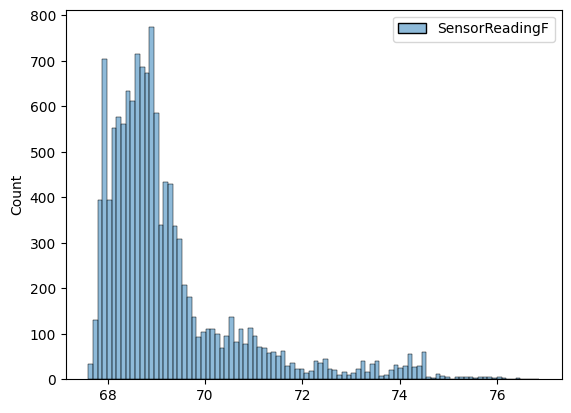

In [9]:
# We can plot the data.
# Let's take this opportunity to use DuckDB to query the parquet file.
import seaborn, duckdb
dt = duckdb.sql("""
    SELECT SensorReadingF 
    FROM read_parquet('data/sensors.parquet') 
    WHERE SensorReadingF is not null and SensorID = 21373;
""")
seaborn.histplot(dt.fetchnumpy())

<Axes: xlabel='SensorReadingUTC', ylabel='SensorReadingF'>

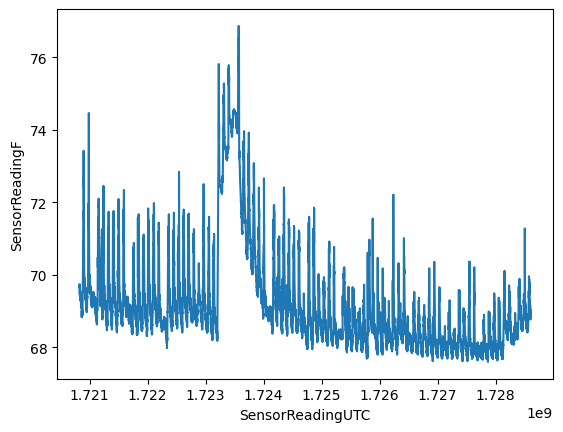

In [10]:
dt = duckdb.sql("""
    SELECT SensorReadingUTC, SensorReadingF 
    FROM read_parquet('data/sensors.parquet') 
    WHERE SensorReadingF is not null and SensorID = 21373;
""")
seaborn.lineplot(x = 'SensorReadingUTC', y= 'SensorReadingF', data=dt.fetchnumpy())

<Axes: xlabel='SensorReadingUTC', ylabel='SensorReadingF'>

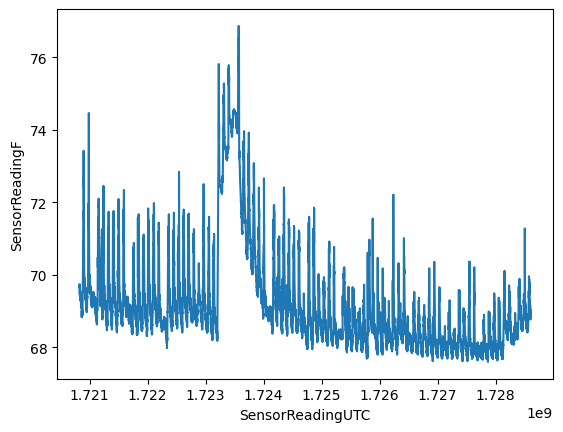

In [11]:
# We could also query devices.
dt = duckdb.sql("""
    SELECT SensorReadingUTC, SensorReadingF 
    FROM read_parquet('data/devices.parquet') 
    WHERE SensorReadingF is not null and DeviceDevID = 12162;
""")
seaborn.lineplot(x = 'SensorReadingUTC', y= 'SensorReadingF', data=dt.fetchnumpy())

In [12]:
# When done, close the connection to the logs. 
envdt.close()